<a href="https://colab.research.google.com/github/glizcano571/int_cc_datos/blob/main/clase6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
#Importamos librerías para poder trabajar el dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#Importamos el dataset

from google.colab import drive
drive.mount('/content/drive')
df_clientes = pd.read_csv('/content/drive/MyDrive/customers_1.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Analísis de Clientes
|Variable|Tipo de Variable|Descripción|
|---|---|---|
|ID|int|Número de identificaición del cliente
|AGE|int|Edad de cada cliente
|Education|Categorical|Nivel de educación de cada cliente
|Income|int|Ingresos anuales de cada cliente
|Occupation|Categorical|El empleo que realiza cada cliente cliente
|Gender|Categorical|El género de cada cliente cliente
|Marital Staturs|Categorical|El estado civíl de cada cliente
|settlement Size|Categorical|Tamaño de ciudad de residencia de cada ciente

In [8]:
#Uso el .info() para entender el tipo de variable con el que cuenta el dataframe
df_clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CustomerID       2000 non-null   int64 
 1   Age              2000 non-null   int64 
 2   Education        2000 non-null   object
 3   Income           2000 non-null   int64 
 4   Occupation       2000 non-null   object
 5   Gender           2000 non-null   object
 6   Marital Status   2000 non-null   object
 7   Settlement Size  2000 non-null   object
dtypes: int64(3), object(5)
memory usage: 125.1+ KB


In [9]:
df_clientes.head()

,CustomerID,Age,Education,Income,Occupation,Gender,Marital Status,Settlement Size
0,1,67,University,124670,Official,Male,Single,Big City
1,2,22,High School,150773,Official,Female,Married,Big City
2,3,49,High School,89210,Unemployed,Male,Single,Small City
3,4,45,High School,171565,Official,Male,Single,Mid City
4,5,53,High School,149031,Official,Male,Single,Mid City


La media de edad de los clientes es de: 36 años
La mediana de edad de los clientes es de: 33 años
--- ANÁLISIS DEMOGRÁFICO DE CLIENTES ---
Edad Media: 35.9 años
Edad Mediana: 33.0 años


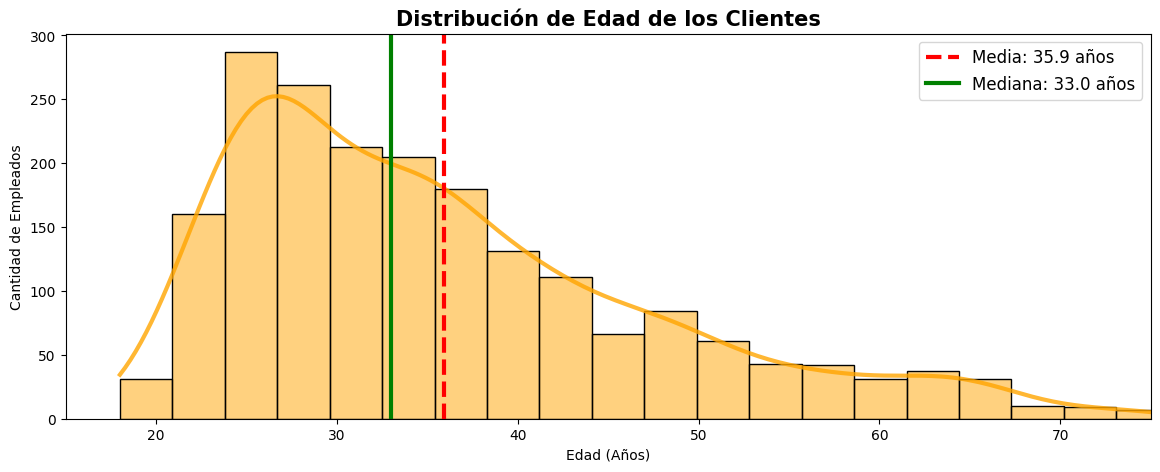

In [10]:
#1.Sacamos media y mediana de edad
media_edad = df_clientes["Age"].mean()
mediana_edad = df_clientes["Age"].median()
print(f"La media de edad de los clientes es de: {media_edad:.0f} años")
print(f"La mediana de edad de los clientes es de: {mediana_edad:.0f} años")

#2.Hacemos analisis de los resultados
print("--- ANÁLISIS DEMOGRÁFICO DE CLIENTES ---")
print(f"Edad Media: {media_edad:.1f} años")
print(f"Edad Mediana: {mediana_edad:.1f} años")

#3.Creamos la gráfica representando el análisis demográfico de los clientes
plt.figure(figsize=(14, 5))
sns.histplot(df_clientes["Age"], bins=20, color="orange", kde=True,
             line_kws={"linewidth": 3, "color": "darkred", "alpha": 0.8})
plt.axvline(media_edad, color="red", linestyle="dashed", linewidth=3,
            label=f"Media: {media_edad:.1f} años")
plt.axvline(mediana_edad, color="green", linestyle="solid", linewidth=3,
            label=f"Mediana: {mediana_edad:.1f} años")
plt.title("Distribución de Edad de los Clientes", fontsize=15, fontweight="bold")
plt.xlabel("Edad (Años)")
plt.ylabel("Cantidad de Empleados")
plt.xlim(15, 75)
plt.legend(fontsize=12)
plt.show()

La media de ingreso de los clientes es de: 120954 dolares
La mediana de ingreso de los clientes es de: 115548 dolares
--- EL EFECTO GRAVEDAD DE LOS MILLONARIOS ---
Media (Promedio Matemático): $120,954.42 USD
Mediana (El empleado del medio): $115,548.50 USD

¿Notas la diferencia? ¡El promedio es engañoso! Parece que todos ganan casi 9 mil dolares.


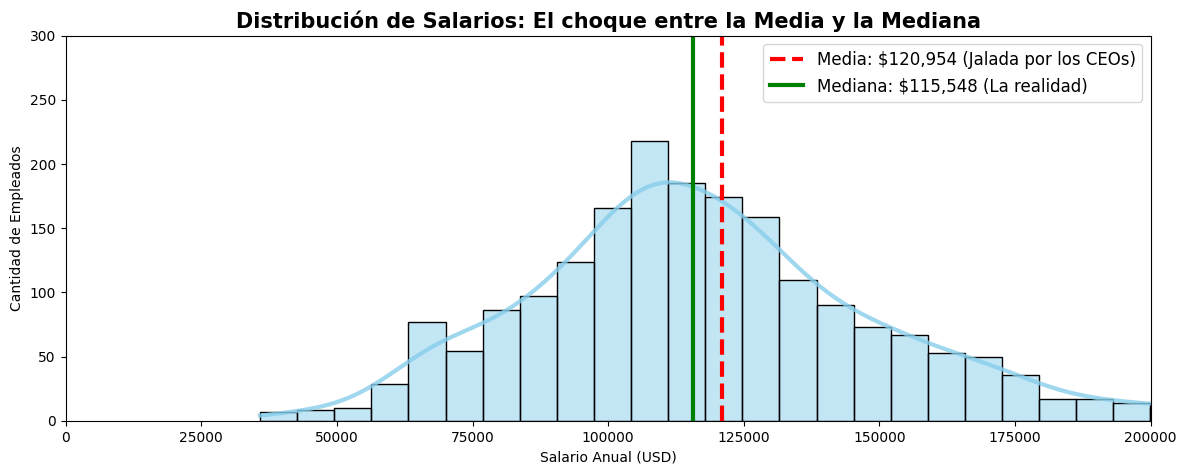

In [11]:
media_ingreso = df_clientes["Income"].mean()
mediana_ingreso = df_clientes["Income"].median()
print(f"La media de ingreso de los clientes es de: {media_ingreso:.0f} dolares")
print(f"La mediana de ingreso de los clientes es de: {mediana_ingreso:.0f} dolares")

# Imprimimos la advertencia inicial
print("--- EL EFECTO GRAVEDAD DE LOS MILLONARIOS ---")
print(f"Media (Promedio Matemático): ${media_ingreso:,.2f} USD")
print(f"Mediana (El empleado del medio): ${mediana_ingreso:,.2f} USD")
print("\n¿Notas la diferencia? ¡El promedio es engañoso! Parece que todos ganan casi 9 mil dolares.")

# #2. Visualización Profesional
plt.figure(figsize=(14, 5))

# Filtramos visualmente para que los CEOs no "aplasten" el gráfico


# Dibujamos el histograma (Nota la coma y el signo = en line_kws)
sns.histplot(df_clientes["Income"], bins=40, color="skyblue", kde=True,
             line_kws={"linewidth": 3, "color": "navy", "alpha": 0.8})

# Dibujamos las lineas marcadas
plt.axvline(media_ingreso, color="red", linestyle="dashed", linewidth=3,
            label=f"Media: ${media_ingreso:,.0f} (Jalada por los CEOs)")
plt.axvline(mediana_ingreso, color="green", linestyle="solid", linewidth=3,
            label=f"Mediana: ${mediana_ingreso:,.0f} (La realidad)")

plt.title("Distribución de Salarios: El choque entre la Media y la Mediana", fontsize=15, fontweight="bold")
plt.xlabel("Salario Anual (USD)")
plt.ylabel("Cantidad de Empleados")
plt.xlim(0, 200000)
plt.ylim(0,300)
plt.legend(fontsize=12)
plt.show()

In [12]:
# Uso el groupby para poder sacar las estadísticas de ingreso por genero,  con media de ingreso y desviación estándar
gender_stats = df_clientes.groupby("Gender")["Income"].agg(["mean", "std"]).round(2)
gender_stats.columns = ["Media_ingresos", "Desviacion_Estandar (riesgo)"]
display(gender_stats)

,Media_ingresos,Desviacion_Estandar (riesgo)
Gender,,
Female,112850.05,34266.33
Male,127775.23,39821.35


/tmp/ipykernel_151/35290680.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x="Gender" , y="Income", data=df_clientes, alpha=0.6, jitter=True, palette="Set1")


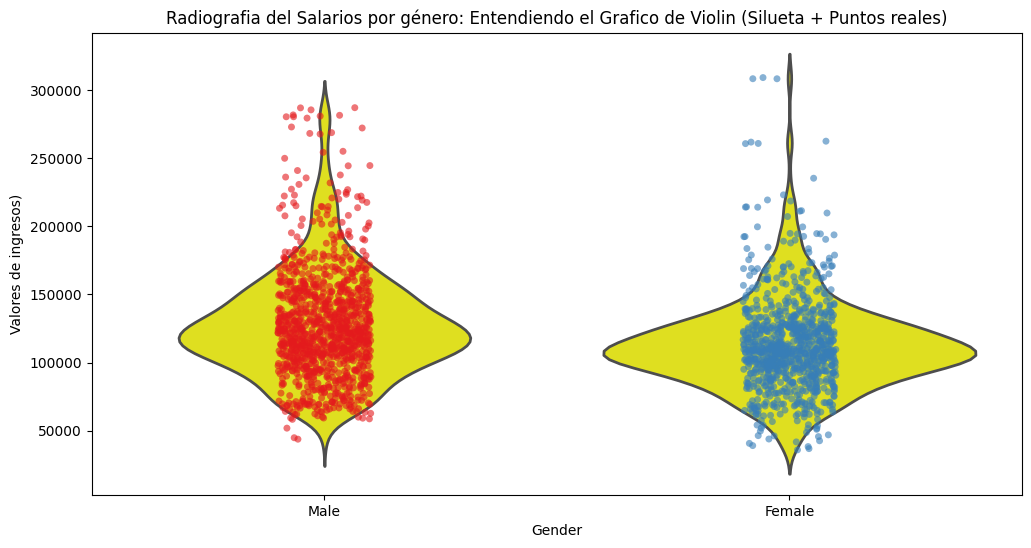

In [13]:
#Visualizacion Didactica: Violin Plot revelado (Superponiendo los puntos reales)
plt.figure(figsize=(12, 6))

#1. Dibujamos el violin "transparente" (la silueta)
sns.violinplot(x="Gender" , y="Income", data=df_clientes, color="yellow", inner=None, linewidth=2)

#2. Superponemos al los clientes reales (los puntos de colores)
sns.stripplot(x="Gender" , y="Income", data=df_clientes, alpha=0.6, jitter=True, palette="Set1")
#3. Generamos el código
plt.title("Radiografia del Salarios por género: Entendiendo el Grafico de Violin (Silueta + Puntos reales)")
plt.ylabel("Valores de ingresos)")
plt.show()

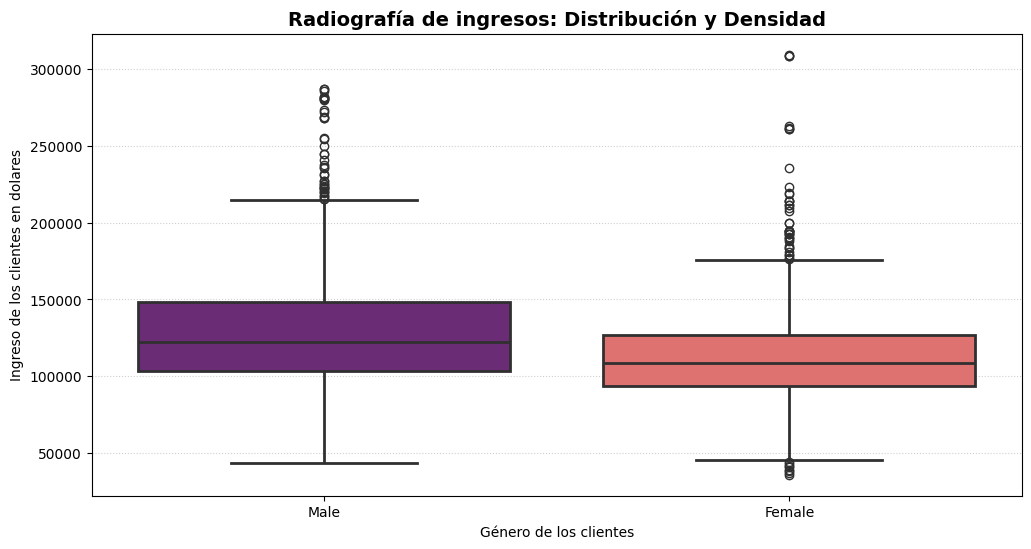

Se podría asegurar que la los clientes masculinos tienen una media de ingreso mayor a los femeninos


In [14]:
#Usamos mismos datos que para el violin pero esta vez para un boxplot de los mismo datos
plt.figure(figsize=(12, 6))


sns.boxplot(x="Gender", y="Income", data=df_clientes, palette = "magma", linewidth=2, hue="Gender")

#. Le ponemos titulo a los ojos y a al gráfico en general
plt.title("Radiografía de ingresos: Distribución y Densidad", fontsize=14, fontweight="bold")
plt.ylabel("Ingreso de los clientes en dolares")
plt.xlabel("Género de los clientes")
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.show()
#Conclusión básica
print("Se podría asegurar que la los clientes masculinos tienen una media de ingreso mayor a los femeninos")

In [15]:
#Cálculo dek estadístico r de pearson
#18 de marzo 2026
correlacion = df_clientes[['Age', 'Income']].corr(method='pearson')
print("MATRIZ DE CORRELACIÓN")
display(correlacion)

MATRIZ DE CORRELACIÓN


,Age,Income
Age,1.00000,0.34061
Income,0.34061,1.00000


<function matplotlib.pyplot.show(close=None, block=None)>

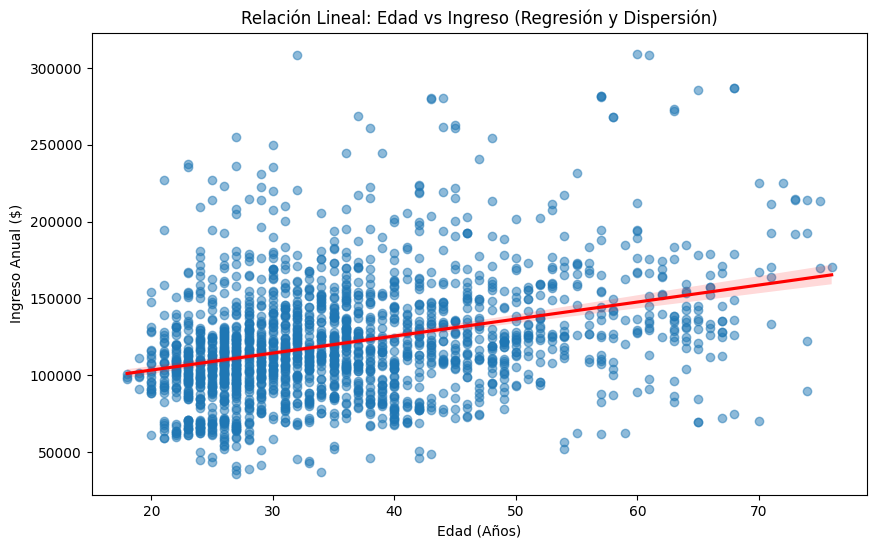

In [16]:
#2. Visualización de la relación (Scatterplot con línea de tendencia)
plt.figure(figsize=(10,6))
sns.regplot(data=df_clientes, x='Age', y='Income', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Relación Lineal: Edad vs Ingreso (Regresión y Dispersión)')
plt.xlabel('Edad (Años)')
plt.ylabel('Ingreso Anual ($)')
plt.show

In [17]:
#Creamos

In [18]:
df_hombres = df_clientes[df_clientes['Gender'] == 'Male']
df_mujeres = df_clientes[df_clientes['Gender'] == 'Female']

<function matplotlib.pyplot.show(close=None, block=None)>

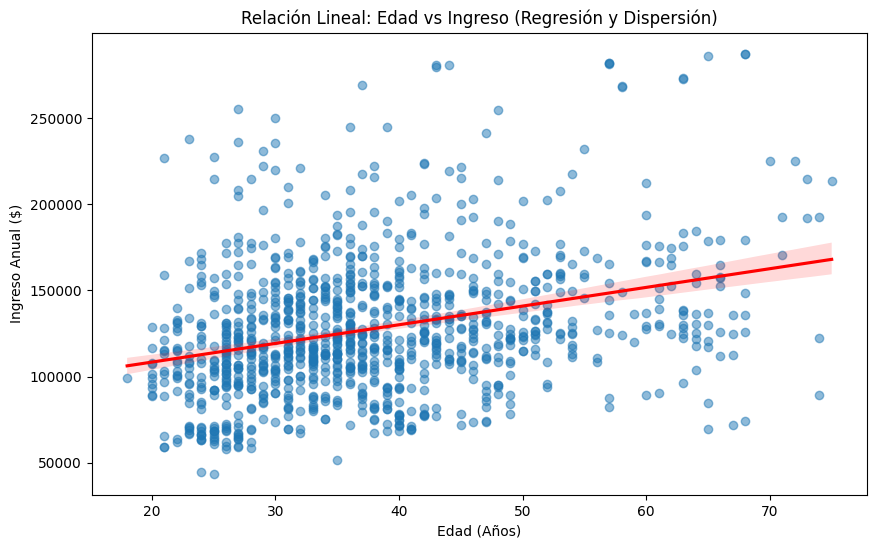

In [19]:
plt.figure(figsize=(10,6))
sns.regplot(data=df_hombres, x='Age', y='Income', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Relación Lineal: Edad vs Ingreso (Regresión y Dispersión)')
plt.xlabel('Edad (Años)')
plt.ylabel('Ingreso Anual ($)')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

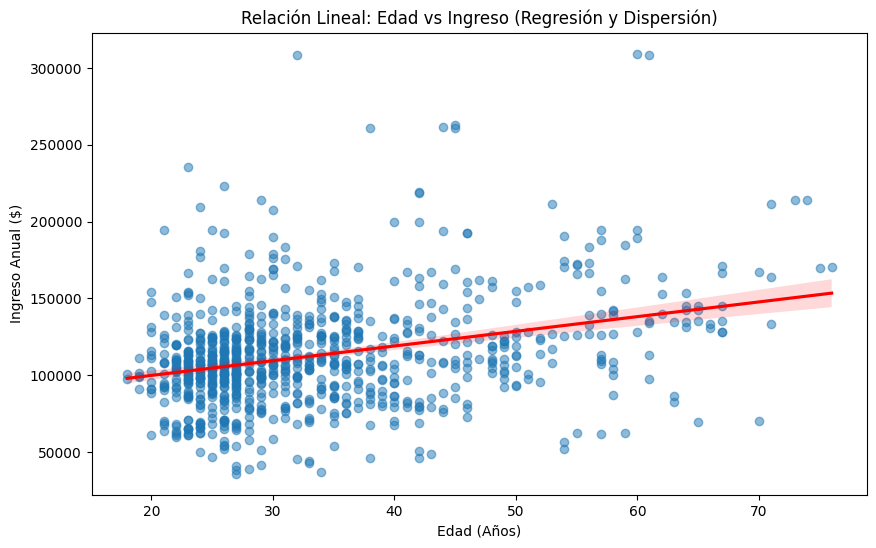

In [20]:
plt.figure(figsize=(10,6))
sns.regplot(data=df_mujeres, x='Age', y='Income', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Relación Lineal: Edad vs Ingreso (Regresión y Dispersión)')
plt.xlabel('Edad (Años)')
plt.ylabel('Ingreso Anual ($)')
plt.show

Text(0, 0.5, 'Ingresos (USD)')

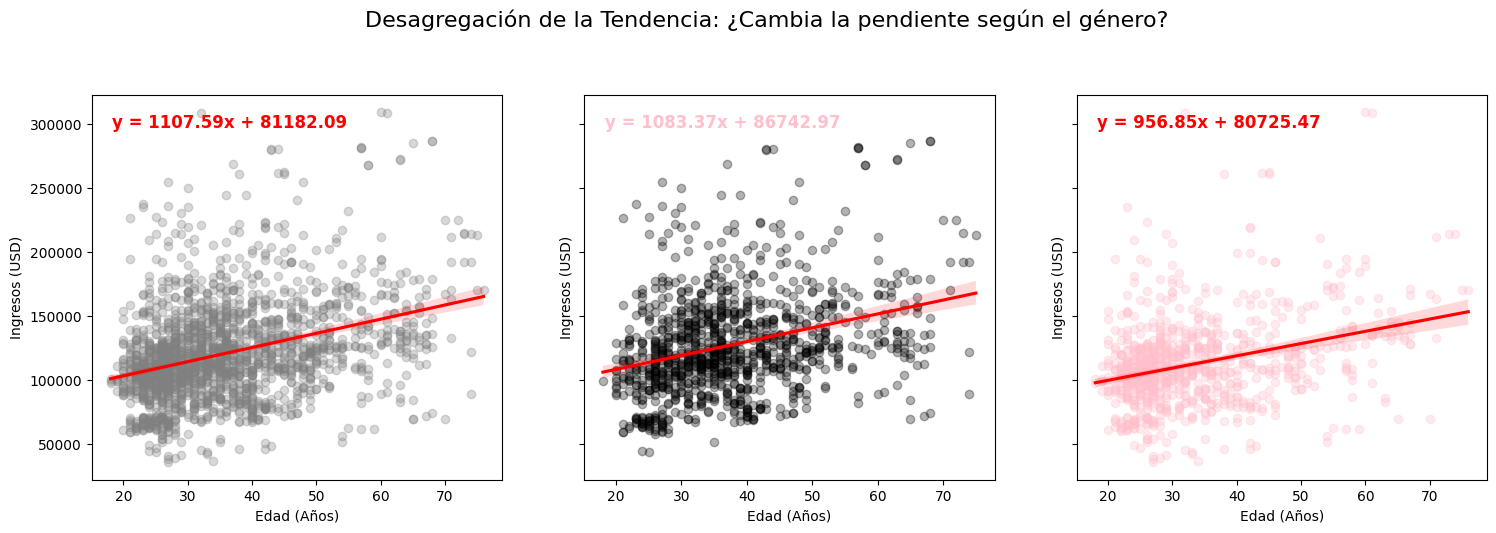

In [30]:
#Creamos una figura con 1 fila y 3 columnas \n"
fig, axes = plt.subplots(1, 3, figsize = (18, 5), sharey=True)
plt.suptitle('Desagregación de la Tendencia: ¿Cambia la pendiente según el género?', fontsize=16, y=1.05)
#1. Plot de todos juntos (Gris y Rojo)\n
sns.regplot(data=df_clientes, x ='Age', y ='Income', ax=axes[0], scatter_kws={'alpha':0.3, 'color':'gray'}, line_kws={'color':'red'})
m1, b1 = np.polyfit(df_clientes['Age'], df_clientes['Income'], 1)
axes[0].text(0.05, 0.95, f'y = {m1:.2f}x + {b1:.2f}', transform=axes[0].transAxes,
             color='red', fontsize=12, fontweight='bold', va = 'top')
axes[0].set_xlabel('Edad (Años)')
axes[0].set_ylabel('Ingresos (USD)')

#2. HOMBRES(Blue)
sns.regplot(data=df_hombres, x ='Age', y ='Income', ax=axes[1], scatter_kws={'alpha':0.3, 'color':'black'}, line_kws={'color':'red'})
m2, b2 = np.polyfit(df_hombres['Age'], df_hombres['Income'], 1)
axes[1].text(1.25, 0.95, f'y = {m2:.2f}x + {b2:.2f}', transform=axes[0].transAxes,
             color='pink', fontsize=12, fontweight='bold', va = 'top')
axes[1].set_xlabel('Edad (Años)')
axes[1].set_ylabel('Ingresos (USD)')

#2 Mujeres(Pink)
sns.regplot(data=df_mujeres, x ='Age', y ='Income', ax=axes[2], scatter_kws={'alpha':0.3, 'color':'pink'}, line_kws={'color':'red'})
m3, b3 = np.polyfit(df_mujeres['Age'], df_mujeres['Income'], 1)
axes[2].text(2.45, 0.95, f'y = {m3:.2f}x + {b3:.2f}', transform=axes[0].transAxes,
             color='red', fontsize=12, fontweight='bold', va = 'top')
axes[2].set_xlabel('Edad (Años)')
axes[2].set_ylabel('Ingresos (USD)')




<Axes: xlabel='Age', ylabel='Income'>

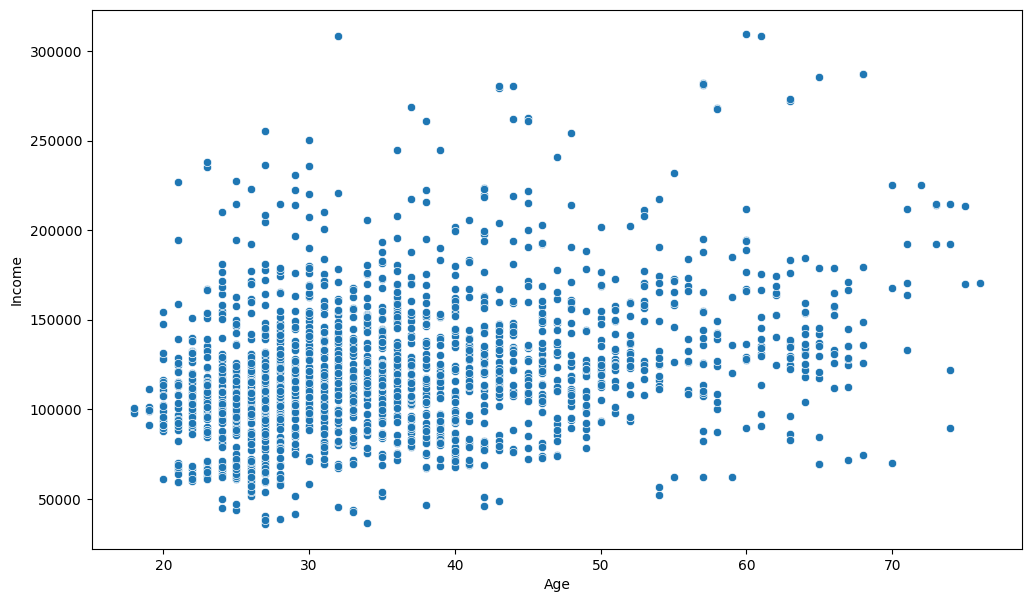

In [22]:
plt.figure(figsize=(12,7))
sns.scatterplot(data=df_clientes, x='Age', y='Income')

<Axes: xlabel='Age', ylabel='Income'>

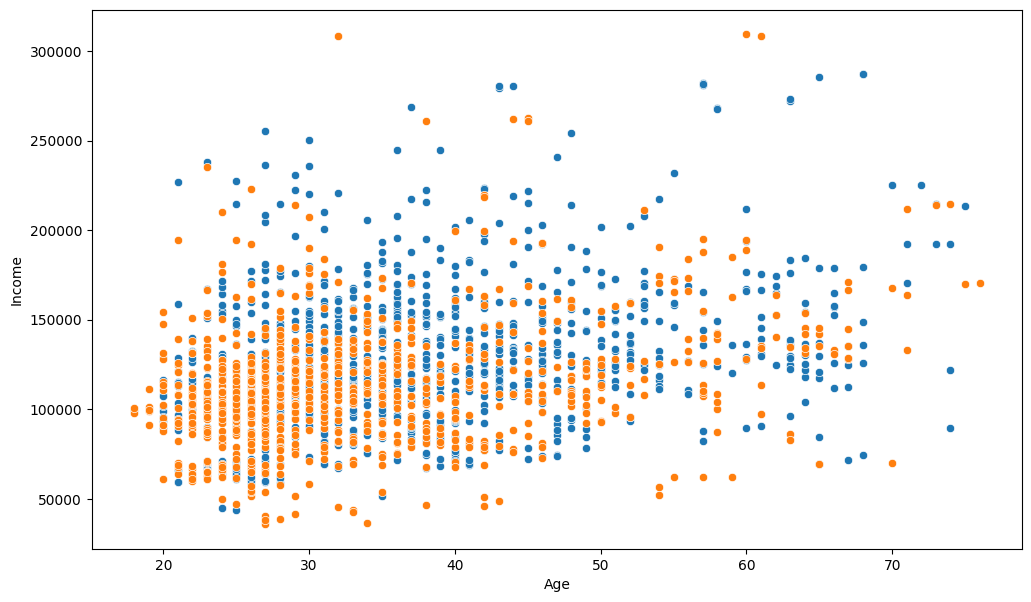

In [23]:
plt.figure(figsize=(12,7))
sns.scatterplot(data=df_hombres, x='Age', y='Income')
sns.scatterplot(data=df_mujeres, x='Age', y='Income')

<Axes: xlabel='Age', ylabel='Income'>

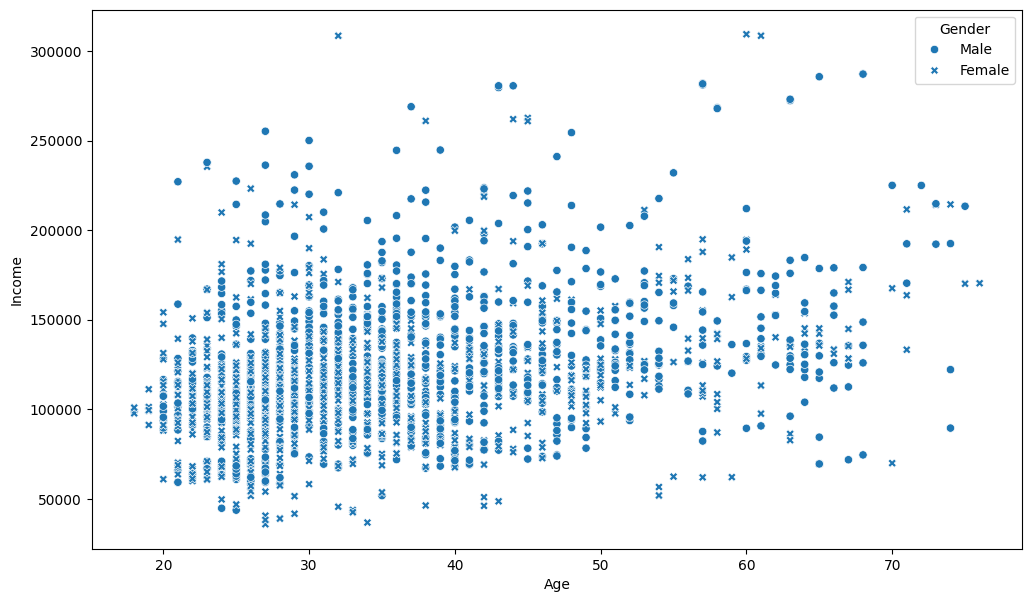

In [24]:
plt.figure(figsize=(12,7))
sns.scatterplot(data=df_clientes, x='Age', y='Income', style='Gender')


<Axes: xlabel='Age', ylabel='Income'>

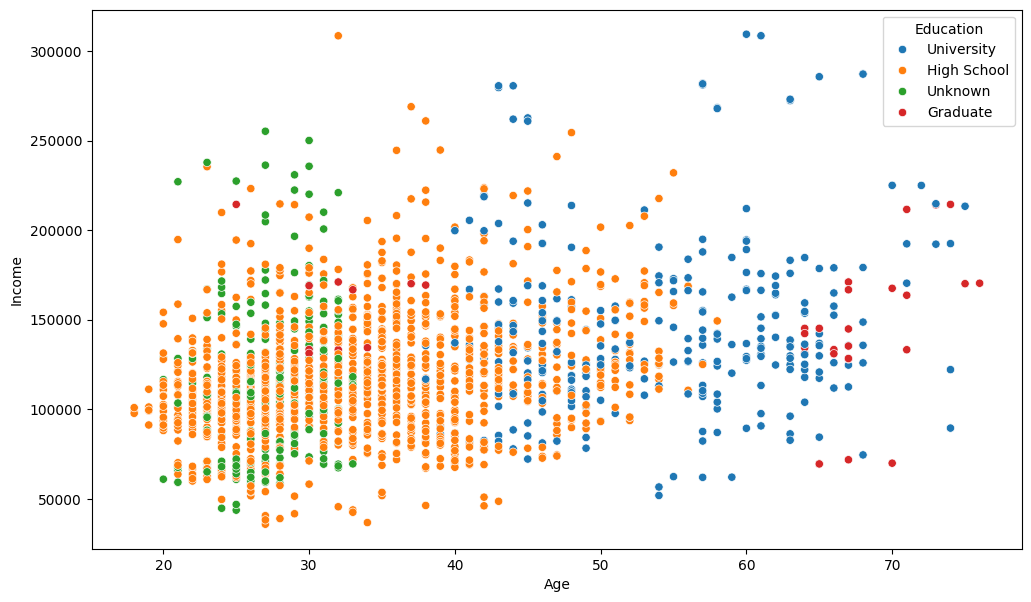

In [25]:
plt.figure(figsize=(12,7))
sns.scatterplot(data=df_clientes, x='Age', y='Income', hue='Education')

<Axes: xlabel='Age', ylabel='Income'>

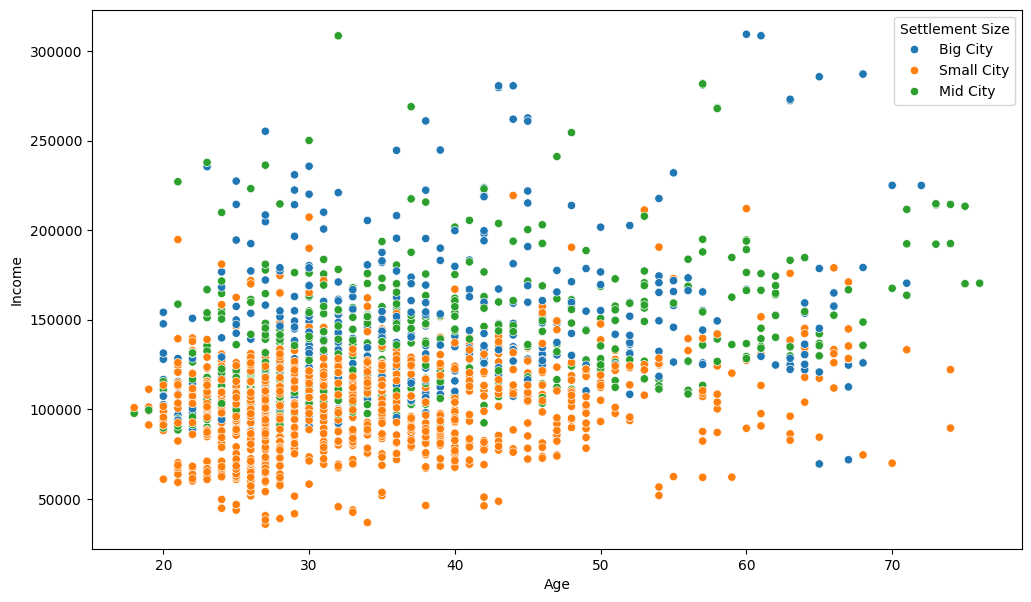

In [26]:
plt.figure(figsize=(12,7))
sns.scatterplot(data=df_clientes, x='Age', y='Income', hue='Settlement Size')

<Axes: xlabel='Age', ylabel='Income'>

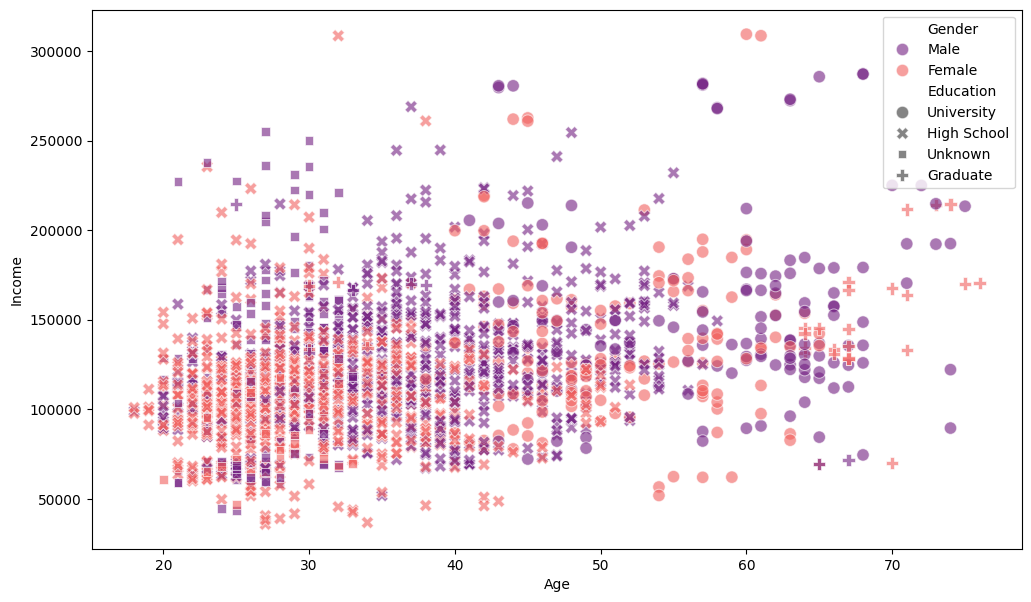

In [27]:
plt.figure(figsize=(12,7))
sns.scatterplot(data=df_clientes, x='Age', y='Income', style='Education', hue= 'Gender',palette="magma", s=80, alpha=0.6)

<Axes: xlabel='Age', ylabel='Income'>

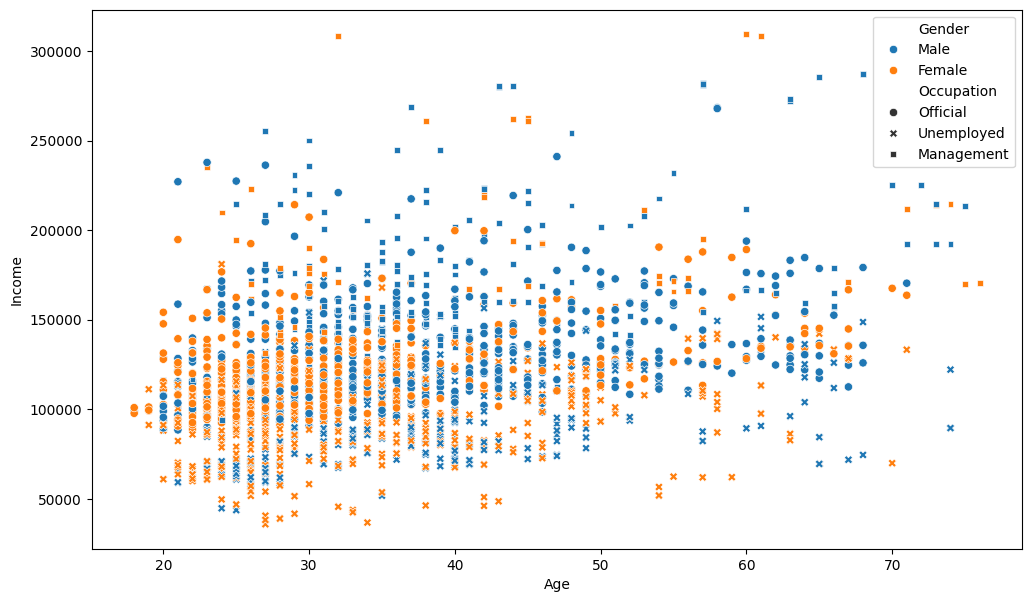

In [28]:
plt.figure(figsize=(12,7))
sns.scatterplot(data=df_clientes, x='Age', y='Income', hue='Gender', style="Occupation")

In [29]:
import plotly.express as px
#Creamos el mismo gráfico disperso pero añadiendo toda la data subyacente al pasar el cursor.
fig = px.scatter(df_clientes, x='Age', y='Income',
                 color='Marital Status',
                 symbol='Gender',
                 hover_data=["Education", 'Occupation', 'Settlement Size'], #Agrega esta info al popup
                 title="Explorador de Clientes Interactivo (Haz hover, clickea la leyenda o haz zoom)")
#Fig.update_layout(template="plotly_white")
fig.show()